# **WSINDy for PDEs: Examples**

- Based on the [JCP paper by **D. A. Messenger**, **D. M. Bortz** (2021)](https://www.sciencedirect.com/science/article/pii/S0021999121004204).
- See the authors' original [MatLab code repository](https://github.com/MathBioCU/WSINDy_PDE).

Seth Minor, 2025

---

This notebook illustrates the Weak SINDy algorithm being applied to various spatiotemporal systems:
- the $(1+1)$-dimensional Kuramoto Sivashinsky equation
- the $(2+1)$-dimensional Swift Hohenberg equation
- the $(3+1)$-dimensional MHD equations

In [1]:
import torch
import scipy
import numpy as np
import itertools
import symengine as sp

import torch.linalg as la
from scipy.signal import convolve
from scipy.special import factorial
import scipy.io as sio
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import sys
import json
from pathlib import Path
try:
    kernel_info_path = Path(sys.argv[-1])
    notebook_path = json.loads(kernel_info_path.read_bytes())['jupyter_session']
    notebook_dir = os.path.dirname(notebook_path)
except (IndexError, KeyError, json.JSONDecodeError, FileNotFoundError):
    # Fallback to current working directory if parsing fails
    notebook_dir = os.getcwd() 
parent_dir = os.path.dirname(notebook_dir)
sys.path.append(parent_dir+'/libs/pywsindy_base')
data_path = parent_dir+'/libs/wsindy_obj_base/pde_data'

from wsindy_smdm import *
from helper_fcns import *

%load_ext autoreload
%autoreload 2

## **KURAMOTO SIVASHINKSY**

In this example, we use data from a numerical solution of the $(1+1)$-dimensional Kuramoto Sivashinsky equation: \begin{align*}
u_t = -\frac{1}{2}\left(u^2\right)_{x} - u_{xx} - u_{xxxx},
\quad \text{for} \quad
\begin{cases}
x \in [0, \, 32\pi],
\\
\, t \in [0, \, 150],
\end{cases}
\end{align*} using periodic boundary conditions. See the `KS.txt` file (1.3 MB) located [here](https://github.com/SethMinor/PyWSINDy-for-PDEs/blob/main/Datasets/KS.txt). These data were sourced from [this GitHub repository](https://github.com/MathBioCU/WSINDy_PDE/blob/master/datasets/KS.mat).

In [2]:
# load data, format with pytorch

dtype = torch.float64
file_path = data_path + '/KS.mat'
mat_contents = sio.loadmat(file_path)

U = mat_contents['U_exact'][0][0]
U = torch.tensor(U,dtype=dtype)
X = mat_contents['xs'][0]
X = [torch.tensor(grid.flatten(),dtype=dtype) for grid in X]

In [3]:
# add noise

noise = 0.25
if noise != 0:
  U = add_noise(U, noise)

Imported tensor with shape (256, 301)


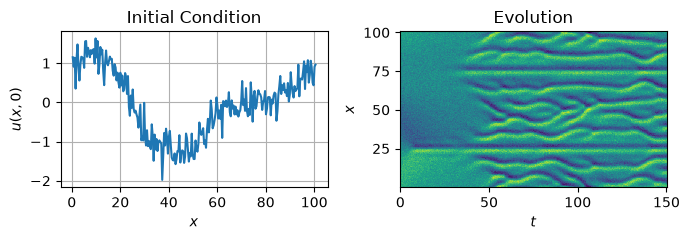

In [4]:
print(f"Imported tensor with shape {U.numpy().shape}")

# Plot the data
fig,ax = plt.subplots(1,2,figsize=(7,2.5))

IC = U[:,1]
ax[0].plot(X[0], U[:,0])
ax[0].set_title('Initial Condition')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$u(x,0)$')
ax[0].grid(True)

Xx,Tt = torch.meshgrid(*X, indexing='ij')
ax[1].pcolormesh(Tt, Xx, U)
ax[1].set_title('Evolution')
ax[1].set_xlabel('$t$')
ax[1].set_ylabel('$x$')

fig.tight_layout()
plt.show()

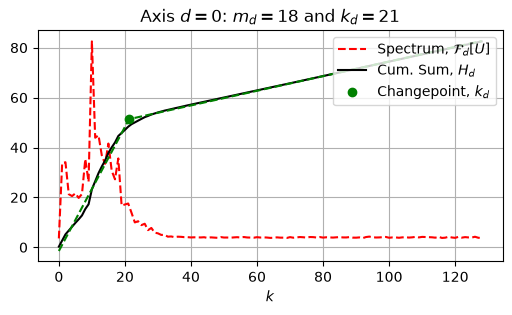

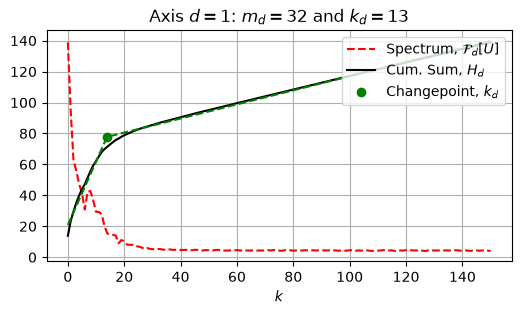

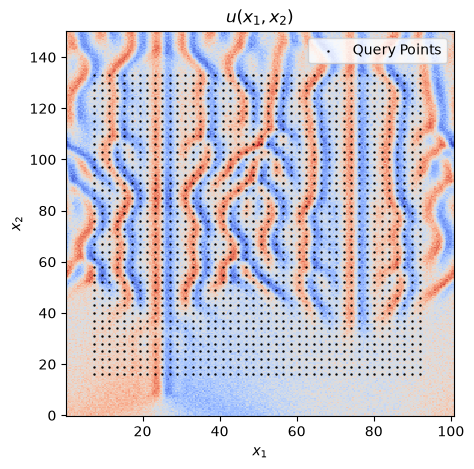

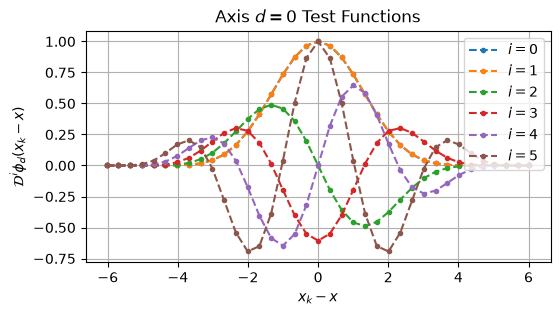

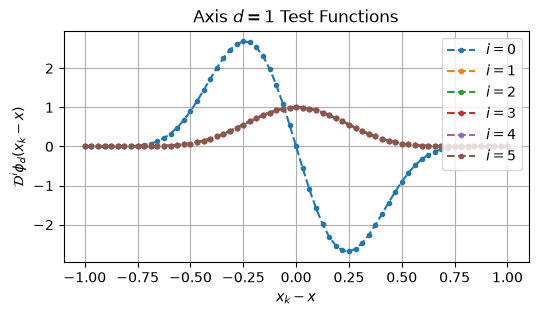

In [5]:
# set LHS and library 

lhs_tag = [1,0,1]

# Derivatives for test fcns
alpha = [lhs_tag[1:]] + get_tags(range(5),[],2,boolT = lambda tag : tag[1] == 0)

# Powers for homogeneous fcns
beta = get_tags(range(4),[],1)

model = WSINDy(U, alpha, beta, X, tau_hat=2)

In [6]:
# CREATE LIBRARY

# Create standard library terms
[G,powers,derivs,rhs_names] = model.create_default_library()

# Add a funky non-homogeneous term, e.g., D^i cos(u)
i = 1
kernel = [model.axes[d][i,:] for d in range(U.ndim)]
yxyt = np.prod(model.yx + [model.yt])
cos_term = compute_weak_trig(U, kernel, model.spacing, freq=1., phase=0., yxyt=yxyt)

G.append(cos_term[model.conv_mask])
powers.append([0])
derivs.append(i)
rhs_names.append(r'\cos(u)' + model.derivative_names[i])

del i, yxyt, kernel, cos_term

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 72.97it/s]


In [7]:
# Display the library in LaTeX
from IPython.display import display, Math

lib_string = r'\Theta=' + r'\{' + r', \, '.join(rhs_names) + r'\}'
display(Math(lib_string))

<IPython.core.display.Math object>

In [8]:
# Set lhs
lhs_name = 'u' + model.derivative_names[0]
model.build_lhs(lhs_name)

# Set library
model.set_library(G, powers, derivs, rhs_names)

# Find sparse weights
Lambdas = torch.Tensor(10**np.linspace(-4,0,50))
w = model.MSTLS(Lambdas=Lambdas)
model.print_report()

HYPER-PARAMETERS
m = [18, 32]
p = [11, 9]
s = [5, 6]
[yx, yt] = [0.853, 0.062]
yu = 0.628
Aux. scales = []

LIBRARY
Num. query points = 1760
Num. terms = 17
cond(G) = 7.671e+01

RESULTS
PDE: u_{t} = - 0.49(u^2)_{x} - 0.98(u)_{xx} - 0.98(u)_{xxxx}
Nonzero terms = 3
Rel. L2 error = 0.168
R^2 = 0.972
Lambda = 2.812e-02
Loss = 0.199


In [9]:
pde = symbolic_pde(model.lhs_name, model.rhs_names, model.coeffs)
display(Math(pde))

<IPython.core.display.Math object>

In [10]:
# Reset variables for next example
del U, model, X, alpha, beta
del powers, derivs, lhs_name, rhs_names, lib_string
del G, w, noise, pde

## **Navier Stokes**

Here we consider the 2D nondimensional N-S vorticity equation with Reynolds number $Re=100$ 
\begin{align*}
\partial_t \omega = -\partial_x(u\omega) -\partial_y(v \omega) + \frac{1}{100}(\partial_{xx}\omega+ \partial_{yy}\omega)
\end{align*}

In [11]:
# load data, format with pytorch

dtype = torch.float64
# file_path = data_path + '/Nav_Stokes.mat'
file_path = '/home/danielmessenger/Dropbox/Boulder/research/data/WSINDy_PDE/datasets/JCP/Nav_Stokes.mat'
mat_contents = sio.loadmat(file_path)

U, V, W = mat_contents['U_exact'][0]
U, V, W = [torch.tensor(Z,dtype=dtype) for Z in [U,V,W]]

X = mat_contents['xs'][0]
X = [torch.tensor(grid.flatten(),dtype=dtype) for grid in X]

In [12]:
# add noise

noise = 0.2
if noise != 0:
  U, V, W = [add_noise(Z, noise) for Z in [U,V,W]]

In [13]:
# print(f"Imported tensor with shape {U.numpy().shape}")

# # Plot the data
# fig,ax = plt.subplots(1,2,figsize=(7,2.5))

# IC = U[:,1]
# ax[0].plot(X[0], U[:,0])
# ax[0].set_title('Initial Condition')
# ax[0].set_xlabel('$x$')
# ax[0].set_ylabel('$u(x,0)$')
# ax[0].grid(True)

# Xx,Tt = torch.meshgrid(*X, indexing='ij')
# ax[1].pcolormesh(Tt, Xx, U)
# ax[1].set_title('Evolution')
# ax[1].set_xlabel('$t$')
# ax[1].set_ylabel('$x$')

# fig.tight_layout()
# plt.show()

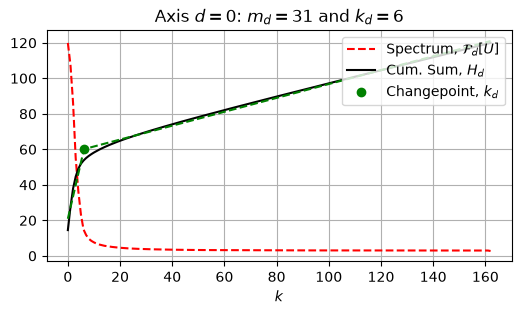

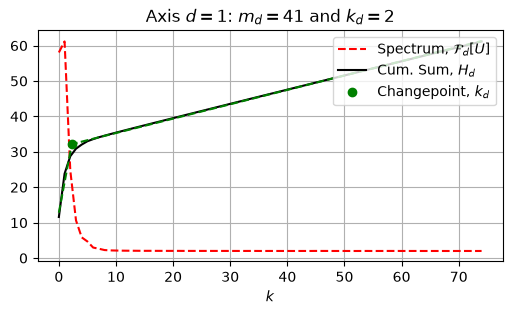

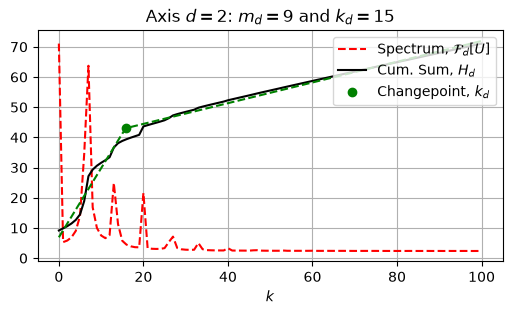

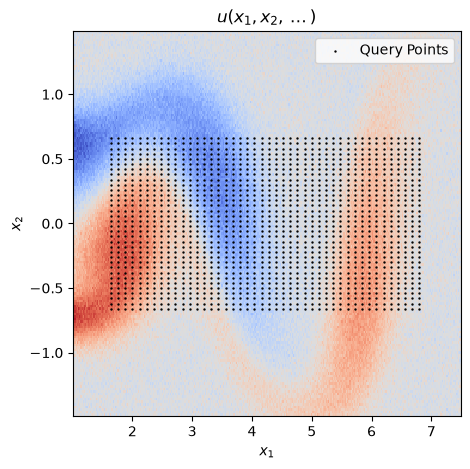

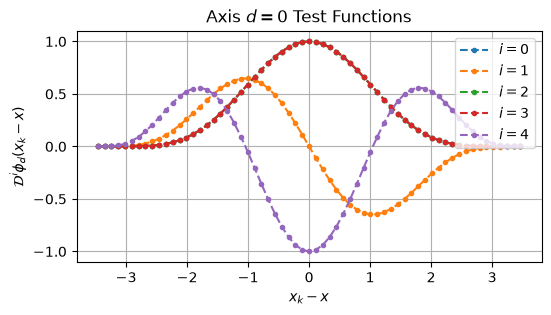

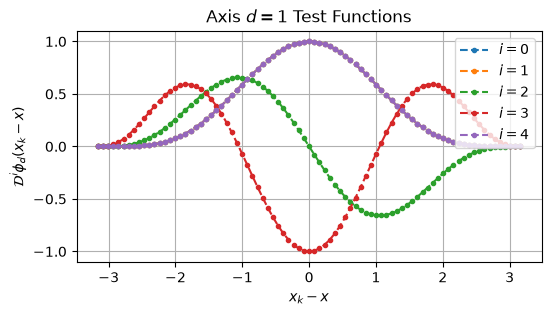

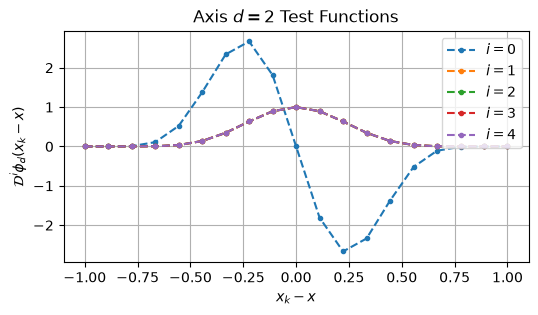

In [14]:
# set library

lhs_tag = [0,0,1,0,0,1]

# Derivatives for test fcns
alpha = [lhs_tag[3:]] + get_tags(range(3),[],3, boolT=lambda tag: (tag[-1]==0) and (bool(tag[0]) ^ bool(tag[1])))

# Powers for homogeneous fcns
beta =  get_tags(range(4),[],3, boolT = lambda tag: tag[0]>0)

model = WSINDy(W, alpha, beta, X, V=[U,V], tau=1e-6, tau_hat=1)

In [15]:
# CREATE LIBRARY

# Create standard library terms
[G,powers,derivs,rhs_names] = model.create_default_library()

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:32<00:00,  8.24s/it]


In [16]:
# Display the library in LaTeX
from IPython.display import display, Math

lib_string = r'\Theta=' + r'\{' + r', \, '.join(rhs_names) + r'\}'
display(Math(lib_string))

<IPython.core.display.Math object>

In [17]:
# Set lhs
lhs_name = 'u' + model.derivative_names[0]
model.build_lhs(lhs_name)

# Set library
model.set_library(G, powers, derivs, rhs_names)

# Find sparse weights
w = model.MSTLS()
model.print_report()

HYPER-PARAMETERS
m = [31, 41, 9]
p = [6, 5, 9]
s = [6, 2, 4]
[yx, yt] = [5.587, 3.856, 0.556]
yu = 0.623
Aux. scales = [0.947, 1.507]

LIBRARY
Num. query points = 68816
Num. terms = 40
cond(G) = 2.753e+02

RESULTS
PDE: u_{t} = - 1.01(u v1)_{x} - 0.97(u v2)_{y} + 0.01(u)_{yy}
Nonzero terms = 3
Rel. L2 error = 0.028
R^2 = 0.999
Lambda = 3.393e-02
Loss = 0.100


In [18]:
pde = symbolic_pde(model.lhs_name, model.rhs_names, model.coeffs)
display(Math(pde))

<IPython.core.display.Math object>